In [6]:
# matplotlib 한글 폰트 설정
import matplotlib
import matplotlib.pyplot as plt

# 사용할 폰트 후보 리스트 (설치된 것만 적용됨)
KOREAN_FONTS = [
    "NanumGothic",
    "Malgun Gothic",
    "AppleGothic",
    "Noto Sans CJK KR",
]

available_fonts = set(f.name for f in matplotlib.font_manager.fontManager.ttflist)
for f in KOREAN_FONTS:
    if f in available_fonts:
        plt.rcParams["font.family"] = f
        break

# 마이너스 깨지는 현상 방지
plt.rcParams["axes.unicode_minus"] = False


In [13]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image


def load_ocr_grounding(exp_dir: str | Path):
    exp_dir = Path(exp_dir)
    with open(exp_dir / "ocr_grounding.json", "r", encoding="utf-8") as f:
        grounding = json.load(f)
    with open(exp_dir / "image_paths.json", "r", encoding="utf-8") as f:
        image_paths = json.load(f)
    return grounding, image_paths


def visualize_ocr_grounding(
    exp_dir: str | Path,
    image_id: str,
    figsize: tuple[float, float] = (8, 8),
):
    """OCR caption + grounding bbox를 한 번에 시각화.

    Args:
        exp_dir: run_ocr_grounding 으로 생성된 exp_~/ 디렉토리 경로
        image_id: ocr_grounding.json / captions.json 의 키 (예: "1-3_cam01_..._capture)10")
    """
    grounding, image_paths = load_ocr_grounding(exp_dir)

    if image_id not in grounding:
        raise KeyError(f"image_id '{image_id}' not found in ocr_grounding.json")

    item = grounding[image_id]
    caption = item.get("caption", "")
    bboxes = item.get("bboxes", [])

    img_path = image_paths.get(image_id)
    if img_path is None:
        raise KeyError(f"image_id '{image_id}' not found in image_paths.json")

    img = Image.open(img_path).convert("RGB")

    plt.figure(figsize=figsize)
    plt.imshow(img)
    ax = plt.gca()

    for bbox in bboxes:
        if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
            continue
        x, y, w, h = bbox
        rect = plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            edgecolor="red",
            linewidth=2,
        )
        ax.add_patch(rect)

    plt.axis("off")
    plt.title(caption, fontsize=10)
    plt.tight_layout()
    plt.show()


# 사용 예시 (실험마다 exp_dir / image_id만 바꿔서 실행)
exp_dir = "outputs/exp_20260317_011201"  # run_ocr_grounding 출력 디렉토리
image_id = "1-3_cam01_fight04_place02_night_spring_capture)2"
visualize_ocr_grounding(exp_dir, image_id)

KeyError: "image_id '1-3_cam01_fight04_place02_night_spring_capture)2' not found in ocr_grounding.json"

In [3]:
# # Grounding 시각화

# Grounding 실험 결과(predictions.json + image_paths.json)를 이미지에 bbox로 시각화합니다.

# 참고:
# - `configs/test_dataset/image_only.yaml` 에 정의된 이미지 리스트
# - `outputs/exp_YYYYMMDD_HHMMSS/` 에 저장된 predictions.json, image_paths.json

In [36]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# 실험 출력 디렉토리 (수정 가능)
EXP_DIR = Path("outputs/exp_20260226_003047")

In [37]:
# predictions.json, image_paths.json 로드
predictions_path = EXP_DIR / "predictions.json"
image_paths_path = EXP_DIR / "image_paths.json"

with open(predictions_path) as f:
    predictions = json.load(f)

with open(image_paths_path) as f:
    image_paths = json.load(f)

print(f"샘플 수: {len(predictions)}")
print("샘플 ID:", list(predictions.keys()))

샘플 수: 2
샘플 ID: ['0Ow4cotKOuw_1_capture', '1-3_cam01_fight04_place02_night_spring_capture']


In [38]:
def visualize_grounding(image_path: str, bboxes: list, ax=None, title: str = ""):
    """
    이미지 위에 bbox를 그립니다.
    bboxes: [[x, y, w, h], ...] 픽셀 좌표 (xywh 형식)
    """
    img = Image.open(image_path).convert("RGB")
    img_arr = np.array(img)

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_arr)
    ax.set_title(title or Path(image_path).name, fontsize=10)

    # xywh: (x,y) 좌상단. matplotlib Rectangle anchor=하단좌측, y축 아래로 증가 → (x, y+h), width=w, height=-h
    for i, bbox in enumerate(bboxes):
        x, y, w, h = bbox
        rect = patches.Rectangle((x, y + h), w, -h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(0, y - 4), str(i + 1), color="lime", fontsize=8, fontweight="bold")

    ax.axis("off")
    if ax is None:
        plt.tight_layout()

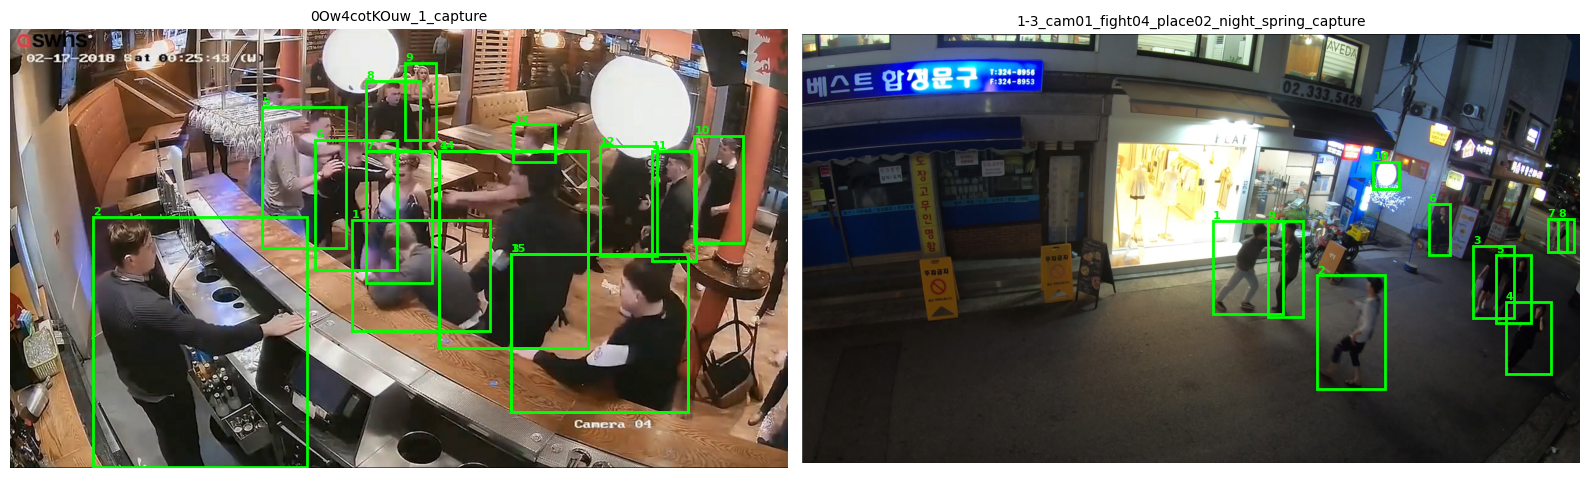

In [39]:
# 모든 샘플 시각화
n = len(predictions)
fig, axes = plt.subplots(1, n, figsize=(8 * n, 6))
if n == 1:
    axes = [axes]
for ax, (sample_id, bboxes) in zip(axes, predictions.items()):
    img_path = image_paths.get(sample_id)
    if not img_path or not Path(img_path).exists():
        ax.text(0.5, 0.5, f"이미지 없음:\n{img_path}", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue
    visualize_grounding(img_path, bboxes if bboxes else [], ax=ax, title=sample_id)
plt.tight_layout()
plt.show()